In [2]:
import os
import pandas as pd
import folium
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

Locality-sensitive hashing

In [3]:
cwd = os.getcwd()
if os.path.basename(cwd) == "Notebooks":
    project_root = os.path.dirname(cwd)
else:
    project_root = cwd
path = os.path.join(project_root, "data", "Airbnb_DK_Processed_Data.csv")
df = pd.read_csv(path)

In [4]:
df['price'] = (
    df['price']
    .astype(str)
    .str.replace('[^\d.]', '', regex=True)  # fjerner alt der ikke er tal eller punktum
    .astype(float)
)

In [5]:
df["estimated_revenue_l365d"][:10]

0         0.0
1     41076.0
2         0.0
3    288990.0
4    211200.0
5     28200.0
6    145080.0
7     91116.0
8         0.0
9    121800.0
Name: estimated_revenue_l365d, dtype: float64

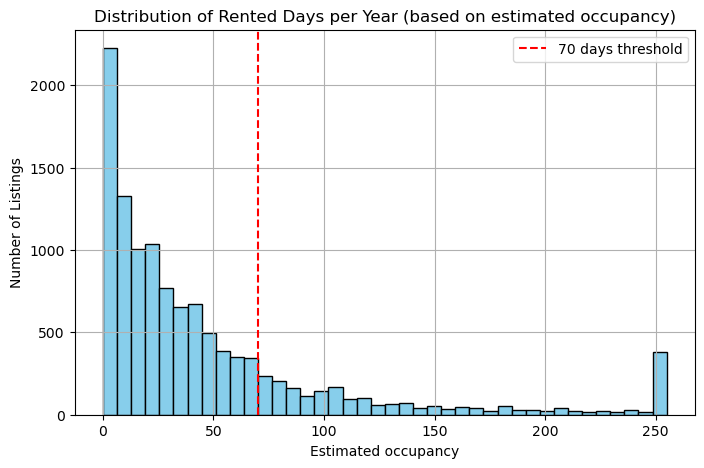

In [33]:
plt.figure(figsize=(8,5))
plt.hist(df["estimated_occupancy_l365d"], bins=40, color="skyblue", edgecolor="black")
plt.axvline(70, color="red", linestyle="--", label="70 days threshold")
plt.title("Distribution of Rented Days per Year (based on estimated occupancy)")
plt.xlabel("Estimated occupancy")
plt.ylabel("Number of Listings")
plt.legend()
plt.grid(True)
plt.show()

In [41]:
over_70 = df[df["estimated_occupancy_l365d"] > 70]
under_70 = df[(df["estimated_occupancy_l365d"] <= 70) & (df["estimated_occupancy_l365d"] > 0)]

print("Avg. host_listing_count (for listing over 70 days):", over_70["host_total_listings_count"].median())
print("Avg. host_listing_count (for listing under 70 days):", under_70["host_total_listings_count"].median())

Avg. host_listing_count (for listing over 70 days): 2.0
Avg. host_listing_count (for listing under 70 days): 1.0


In [ ]:
plt.hist(over_70["host_total_listings_count"], bins=40, color="skyblue", edgecolor="black")
plt.axvline(70, color="red", linestyle="--", label="70 days threshold")
plt.title("Distribution of Rented Days per Year (based on estimated occupancy)")
plt.xlabel("Estimated occupancy")
plt.ylabel("Number of Listings")
plt.legend()
plt.grid(True)
plt.show()

/var/folders/g9/wl8_th957sb253jg5r8b8t5w0000gn/T/ipykernel_27257/3393894721.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


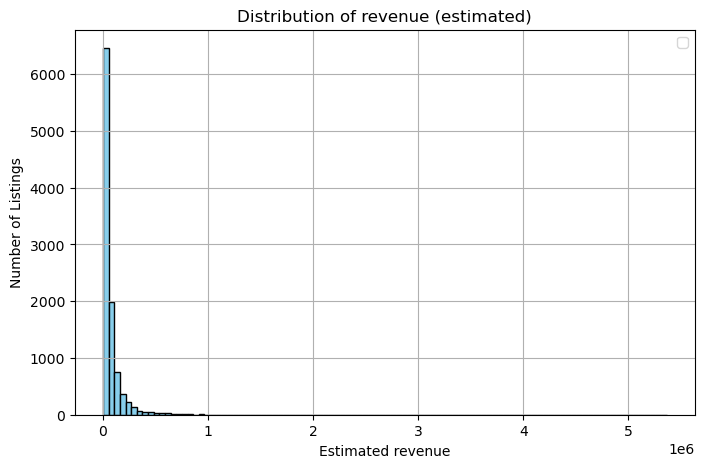

In [38]:
df_nonull_revenue = df[df["estimated_revenue_l365d"] > 0]
plt.figure(figsize=(8,5))
plt.hist(df_nonull_revenue["estimated_revenue_l365d"], bins=100, color="skyblue", edgecolor="black")
plt.title("Distribution of revenue (estimated)")
plt.xlabel("Estimated revenue")
plt.ylabel("Number of Listings")
plt.legend()
plt.grid(True)
plt.show()

In [43]:
df_host_more_than_3 = df[df["host_total_listings_count"] > 3]
df_host_3_or_less = df[df["host_total_listings_count"] <= 3]

In [62]:
print(df.duplicated(subset="host_id").sum())
print(df_host_more_than_3.duplicated(subset="host_id").sum())
print(df_host_3_or_less.duplicated(subset="host_id").sum())

1179
939
231


In [49]:
print(f"Number of listings where host has more than 3 listings:", len(df_host_more_than_3))
print(f"Number of listings where host has 3 or less listings:", len(df_host_3_or_less))

Number of listings where host has more than 3 listings: 1622
Number of listings where host has 3 or less listings: 9619


In [16]:
host_activity = df.groupby('host_id').agg({
    'id': 'count',
    'availability_365': 'mean',
    'minimum_nights': 'mean',
    'maximum_nights': 'mean',
    'reviews_per_month': 'mean',
    'price': 'mean',
    'estimated_revenue_l365d': 'mean'
}).rename(columns={'id': 'num_listings'}).round(2)

In [33]:
commercial_hosts = host_activity[host_activity['num_listings'] > 7]
commercial_hosts.describe().round(2)

,num_listings,availability_365,minimum_nights,maximum_nights,reviews_per_month,price,estimated_revenue_l365d
count,31.00,31.00,31.00,31.00,31.00,31.00,31.00
mean,20.03,255.81,4.41,532.82,2.30,2067.20,266579.24
std,30.59,79.58,8.03,288.59,1.30,964.97,215447.17
min,8.00,8.89,1.00,81.00,0.30,236.67,17467.80
25%,9.00,208.46,1.00,365.00,1.40,1410.56,82660.90
50%,10.00,293.90,1.90,418.89,2.29,2173.11,262245.92
75%,15.00,314.70,2.88,710.58,3.55,2563.06,382330.45
max,174.00,357.87,31.00,1125.00,5.12,4484.78,1017387.33


In [32]:
medium_hosts = host_activity[(host_activity['num_listings'] > 2) & (host_activity['num_listings'] <= 7)]
medium_hosts[:20]
medium_hosts.describe().round(2)

,num_listings,availability_365,minimum_nights,maximum_nights,reviews_per_month,price,estimated_revenue_l365d
count,106.00,106.00,106.00,106.00,106.00,106.00,106.00
mean,4.08,215.93,3.95,486.31,2.76,1790.62,178524.54
std,1.27,96.80,7.27,342.68,3.74,1302.91,188385.09
min,3.00,0.00,1.00,5.00,0.04,262.50,0.00
25%,3.00,152.38,1.00,304.55,0.70,954.08,42555.80
50%,4.00,234.70,1.67,365.00,1.58,1450.48,119481.25
75%,5.00,296.14,3.00,619.58,3.36,2402.52,248077.75
max,7.00,365.00,51.25,1125.00,29.17,8882.25,979500.00


In [30]:
private_hosts = host_activity[host_activity['num_listings'] <= 2]
private_hosts[:20]
private_hosts.describe().round(2)

,num_listings,availability_365,minimum_nights,maximum_nights,reviews_per_month,price,estimated_revenue_l365d
count,10265.00,10265.00,10265.00,10265.00,10265.00,10265.00,10265.00
mean,1.03,122.16,3.94,262.34,0.80,1342.20,53343.81
std,0.16,112.68,11.31,338.22,0.95,1262.52,72731.89
min,1.00,0.00,1.00,1.00,0.01,202.00,0.00
25%,1.00,19.00,2.00,17.00,0.25,900.00,12600.00
50%,1.00,85.00,3.00,60.00,0.50,1156.00,31350.00
75%,1.00,202.00,4.00,365.00,1.00,1543.00,65088.00
max,2.00,365.00,730.00,1125.00,19.47,100000.00,1211250.00
